In [169]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize

import astropy.units as u
from matplotlib.colors import TwoSlopeNorm

from tqdm import tqdm

Column 1:  magnetic flux values given in integer multiples of 1e17 Maxwells

Column 2:  x_i  (in units of Mm)

Column 3:  y_i  (in units of Mm)

In [364]:
filename = 'data/full_xi0.99.out'
df = pd.read_csv(filename, sep='  ', skiprows=2, names=['Phi_i', 'x_i', 'y_i'], engine='python')

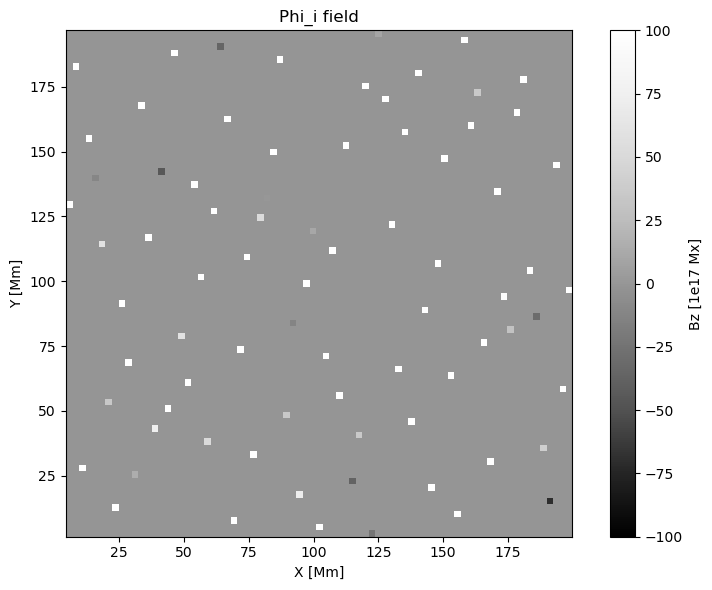

In [365]:
# Pivot to 2D grid: rows = unique y values, cols = unique x values
grid = df.pivot(index='y_i', columns='x_i', values='Phi_i').fillna(0)

plt.figure(figsize=(8, 6))
plt.imshow(grid, origin='lower',  # 'lower' puts y=0 at bottom
           aspect='equal',
           extent=[grid.columns.min(), grid.columns.max(),
                   grid.index.min(),   grid.index.max()], 
           cmap='Greys_r', 
           vmin=-100, 
           vmax=100)
plt.colorbar(label='Bz [1e17 Mx]')
plt.xlabel('X [Mm]')
plt.ylabel('Y [Mm]')
plt.title('Phi_i field')
plt.tight_layout()
plt.show()

In [366]:
def calc_B(df, z):
    # Define your evaluation grid
    x_vals = np.linspace(df.x_i.min(), df.x_i.max(), 200)
    y_vals = np.linspace(df.y_i.min(), df.y_i.max(), 200)
    
    X, Y = np.meshgrid(x_vals, y_vals)  # shape (ny, nx)
    
    # Evaluation points r = (x, y, z)
    rx = X[..., np.newaxis]  # (ny, nx, 1)
    ry = Y[..., np.newaxis]
    rz = np.full_like(rx, z)
    
    # Source positions r_i = (x_i, y_i, 0)
    xi = df.x_i.values  # (n_sources,)
    yi = df.y_i.values
    phi = df.Phi_i.values
    
    # Displacement vectors r - r_i, shape (ny, nx, n_sources)
    dx = rx - xi
    dy = ry - yi
    dz = rz - (-1.0)  # sources assumed at z=-1.0
    
    dist = np.sqrt(dx**2 + dy**2 + dz**2)  # (ny, nx, n_sources)
    
    # Sum over sources: B = sum_i (Phi_i / 2pi) * (r - r_i) / |r - r_i|^3
    weight = phi / (2 * np.pi) / dist**3  # (ny, nx, n_sources)
    
    Bx = np.sum(weight * dx, axis=-1)  # (ny, nx)
    By = np.sum(weight * dy, axis=-1)
    Bz = np.sum(weight * dz, axis=-1)
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    return Bx, By, Bz, Bmag

In [367]:
z = (6.1 * 10**6 * u.km).to(u.Mm).value # ~ PSP height
# z = (10 * u.R_sun).to(u.Mm).value # ~ PSP height
# z = 10
Bx, By, Bz, Bmag = calc_B(df, z=z)

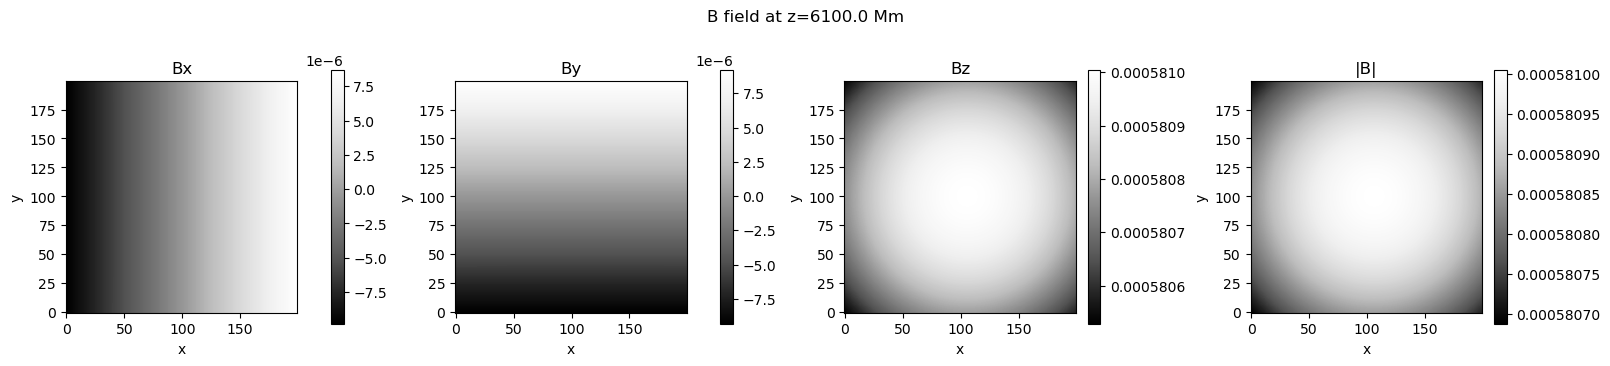

In [368]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout='compressed')

for ax, data, title in zip(axes, [Bx, By, Bz, Bmag], ['Bx', 'By', 'Bz', '|B|']):
    im = ax.imshow(data, origin='lower', aspect='equal', cmap='Greys_r')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'B field at z={z} Mm')
plt.show()

In [369]:
# =============================================================================
# LOAD DATA
# =============================================================================

filename = filename
df = pd.read_csv(filename, sep=r'\s+', skiprows=2,
                 names=['Phi_i', 'x_i', 'y_i'], engine='python')

xi = df.x_i.values
yi = df.y_i.values
phi = df.Phi_i.values
Z_SOURCES = -1.0   # Mm below photosphere
GAUSS = 10.0 * 1e5  # 1e17 Mx/Mm² → nanoTesla

# =============================================================================
# CORE FUNCTION
# =============================================================================

def calc_B(x, y, z, xi, yi, phi, z_sources=Z_SOURCES):
    """
    Compute B vector at arbitrary points (x, y, z).

    x, y, z : floats or arrays of shape (...)
    xi, yi  : source positions, shape (n,)
    phi     : source fluxes,    shape (n,)

    Returns Bx, By, Bz in nT (same shape as x).
    """
    # add trailing source axis so broadcasting works
    x = np.asarray(x)[..., np.newaxis]
    y = np.asarray(y)[..., np.newaxis]
    z = np.asarray(z)[..., np.newaxis]

    dx = x - xi
    dy = y - yi
    dz = z - z_sources

    dist   = np.sqrt(dx**2 + dy**2 + dz**2)
    weight = phi / (2 * np.pi) / dist**3

    Bx = np.sum(weight * dx, axis=-1) * GAUSS
    By = np.sum(weight * dy, axis=-1) * GAUSS
    Bz = np.sum(weight * dz, axis=-1) * GAUSS
    return Bx, By, Bz

# =============================================================================
# GRID + SLICES
# =============================================================================

def make_grid(nx=100, ny=100):
    x = np.linspace(xi.min(), xi.max(), nx)
    y = np.linspace(yi.min(), yi.max(), ny)
    return np.meshgrid(x, y)   # X, Y each (ny, nx)

def compute_slices(z_values, X, Y):
    """Return list of Bz grids, one per z in z_values."""
    slices = []
    for z in z_values:
        _, _, Bz = calc_B(X, Y, z, xi, yi, phi)
        slices.append(Bz)
    return slices

# =============================================================================
# PSP TRAJECTORY
# =============================================================================

def make_psp_trajectory(z_psp, speed=0.2, y_offset=0.0, dt=1.0):
    """
    Straight-line PSP pass at fixed height z_psp.
    speed     : Mm/s  (default 0.2 Mm/s ~ 200 km/s)
    y_offset  : shift from domain midplane in Mm
    Returns t, x_psp, y_psp, z_psp_arr
    """
    x_start, x_end = xi.min(), xi.max()
    t_total = (x_end - x_start) / speed
    t       = np.arange(0, t_total, dt)

    x_psp     = np.linspace(x_start, x_end, len(t))
    y_psp     = np.full_like(t, (yi.min() + yi.max()) / 2 + y_offset)
    z_psp_arr = np.full_like(t, z_psp)
    return t, x_psp, y_psp, z_psp_arr

# =============================================================================
# PLOT
# =============================================================================

def plot_psp(z_psp, n_slices=6, speed=0.2, y_offset=0.0):

    X, Y = make_grid()
    z_values = np.linspace(1.0, z_psp, n_slices)   # start at 1 to avoid near-singularity
    slices   = compute_slices(z_values, X, Y)

    # PSP trajectory + measured Bz
    t, x_psp, y_psp, z_psp_arr = make_psp_trajectory(z_psp, speed, y_offset)
    Bx_psp, By_psp, Bz_psp = calc_B(x_psp, y_psp, z_psp_arr, xi, yi, phi)
    Bmag_psp = np.sqrt(Bx_psp**2 + By_psp**2 + Bz_psp**2)

    # ---- figure ----
    fig = plt.figure(figsize=(14, 6))
    ax3d = fig.add_subplot(121, projection='3d')
    ax_ts = fig.add_subplot(122)

    # stacked slices
    for z, Bz in zip(z_values, slices):
        vmax = np.max(np.abs(Bz))
        norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
        colors = plt.cm.Greys_r(norm(Bz))
        colors[..., 3] = 1.0  # alpha
        ax3d.plot_surface(X, Y, np.full_like(X, z),
                          facecolors=colors,
                          rstride=1, cstride=1,
                          linewidth=0, antialiased=False)
        # # border
        # x_min, x_max = X[0, 0], X[0, -1]
        # y_min, y_max = Y[0, 0], Y[-1, 0]
        # corners_x = [x_min, x_max, x_max, x_min, x_min]
        # corners_y = [y_min, y_min, y_max, y_max, y_min]
        # corners_z = [z] * 5
        # ax3d.plot(corners_x, corners_y, corners_z, color='k', lw=2, alpha=1)

    # PSP trajectory
    ax3d.plot(x_psp, y_psp, z_psp_arr, color='red', lw=2, label='PSP', zorder=100)
    ax3d.plot([x_psp[-1]], [y_psp[-1]], [z_psp_arr[-1]],
              marker=(3, 0, 0),
              color='red', markersize=8, zorder=100)

    ax3d.set_xlabel('x (Mm)')
    ax3d.set_ylabel('y (Mm)')
    ax3d.set_zlabel('z (Mm)')
    ax3d.set_title('Bz slices + PSP trajectory')
    ax3d.legend(loc='upper left', framealpha=0)

    # Bz timeseries
    ax_ts.plot(t, Bx_psp, color='#D81B60', lw=1, label='Bx')
    ax_ts.plot(t, By_psp, color='#1E88E5', lw=1, label='Bz')
    ax_ts.plot(t, Bz_psp, color='#FFC107', lw=1, label='Bz')
    ax_ts.plot(t, Bmag_psp, color='k', lw=1, label='Bmag')
    
    ax_ts.axhline(0, color='gray', lw=1, ls='--')
    ax_ts.set_xlabel('Time (s)')
    ax_ts.set_ylabel('(nT)')
    ax_ts.set_title(f'Bz measured by PSP  (z = {z_psp:.0f} Mm)')
    ax_ts.grid(True, alpha=0.3)
    ax_ts.legend()
    ax_ts.set_xlim(0, max(t))

    plt.tight_layout()
    plt.show()

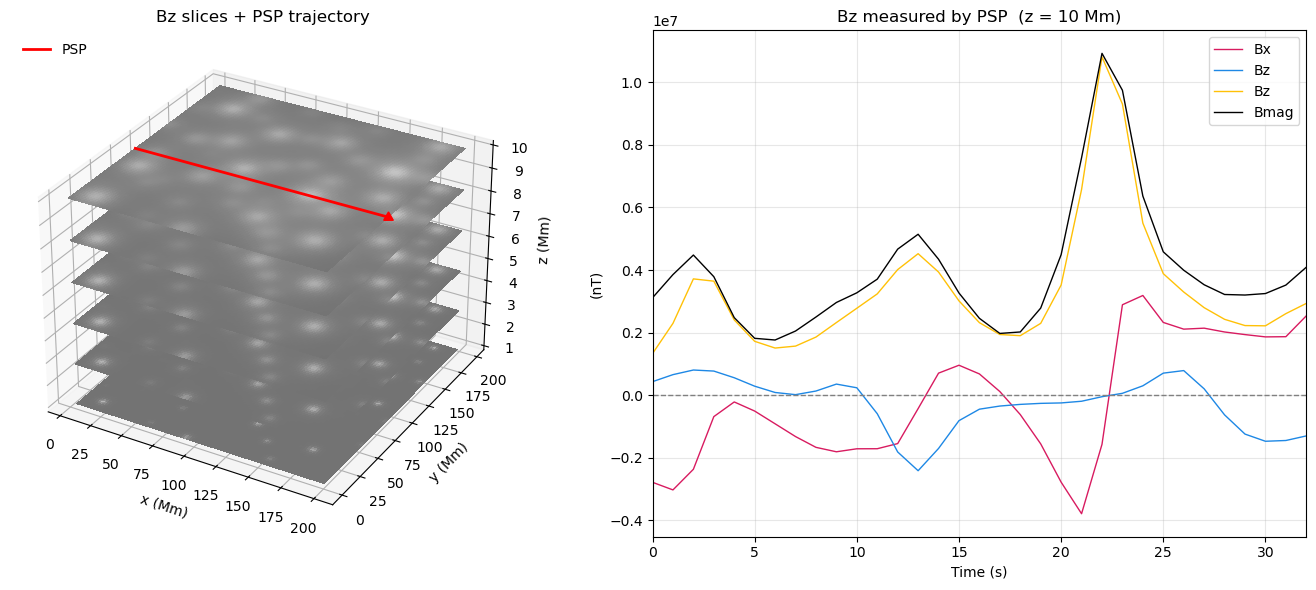

In [370]:
# =============================================================================
# RUN
# =============================================================================

speed = (692000 * u.km/u.s).to(u.Mm/u.s).value
z_psp = (6.1 * 10**6 * u.km).to(u.Mm).value

plot_psp(
    z_psp    = 10,   # Mm
    n_slices = 6,
    speed    = 6,    # Mm/s
    y_offset = -15.0,  # Mm from midplane
)

small length and follow it -- comput field and direction and follow it down
top most Bz mus be pointed downwards and carry that sign through
whats the optimal size

vector tracing

spacecraft constant speed, each point on the surface different speed
does that speed correlate with the field strength when it gets to the bottom

scatterplot of field strength vs percieved speed of footpoint

In [408]:
def trace_fieldline(x0, y0, z0, xi, yi, phi,
                    ds=1.0, z_stop=0.0):
    """
    Trace a field line from (x0, y0, z0) down to z_stop.
    ds       : step size in Mm — smaller = more accurate but slower
    Returns arrays of (x, y, z) along the field line.
    """
    pos = np.array([x0, y0, z0], dtype=float)
    path = [pos.copy()]

    # max_steps = int(30 * (z0 - z_stop) / ds) # x10
    curr_z = z0
    
    sign = None

    # for i in range(max_steps):
    while curr_z > z_stop:
        Bx, By, Bz = calc_B(pos[0], pos[1], pos[2], xi, yi, phi)
        B = np.array([Bx, By, Bz])
        Bmag = np.sqrt(np.sum(B**2))

        # if Bmag == 0:
        #     break

        b_hat = B / Bmag

        # determine sign once at the start and keep it for the whole trace
        if sign is None:
            sign = -1 if b_hat[2] > 0 else +1

        pos = pos + ds * sign * b_hat
        path.append(pos.copy())

        curr_z = pos[2]

        # if pos[2] <= z_stop:
        #     break

    return np.array(path)


def trace_all_footpoints(x_psp, y_psp, z_psp_arr, xi, yi, phi,
                          ds=5.0, subsample=10):
    """
    Trace field line from each PSP position down to z=0.
    subsample : only trace every Nth PSP point (saves time)
    Returns footpoints (x_foot, y_foot) and field strength at footpoint.
    """
    idx = np.arange(0, len(x_psp), subsample)

    x_foot  = np.zeros(len(idx))
    y_foot  = np.zeros(len(idx))
    B_foot  = np.zeros(len(idx))   # |B| at footpoint
    B_psp   = np.zeros(len(idx))   # |B| at PSP height

    for n, i in enumerate(tqdm(idx)):
        # |B| at PSP
        Bx, By, Bz = calc_B(x_psp[i], y_psp[i], z_psp_arr[i], xi, yi, phi)
        B_psp[n] = np.sqrt(Bx**2 + By**2 + Bz**2)

        # trace down
        path = trace_fieldline(x_psp[i], y_psp[i], z_psp_arr[i],
                                xi, yi, phi, ds=ds)

        x_foot[n] = path[-1, 0]
        y_foot[n] = path[-1, 1]

        # |B| at footpoint
        Bx, By, Bz = calc_B(path[-1, 0], path[-1, 1], path[-1, 2],
                              xi, yi, phi)
        B_foot[n] = np.sqrt(Bx**2 + By**2 + Bz**2)

    return x_foot, y_foot, B_foot, B_psp, idx


def plot_fieldline_traces(x_psp, y_psp, z_psp_arr, t, xi, yi, phi,
                          ds=5.0, subsample=10):

    idx = np.arange(0, len(x_psp), subsample)

    # compute Bz at photosphere for the floor
    X, Y = make_grid()
    _, _, Bz_floor = calc_B(X, Y, 0.0, xi, yi, phi)  # z=0.1 to avoid singularity
    vmax = np.max(np.abs(Bz_floor))
    norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    floor_colors = plt.cm.Greys_r(norm(Bz_floor))
    floor_colors[..., 3] = 1.0

    fig = plt.figure(figsize=(15, 8), layout='compressed')
    ax = fig.add_subplot(121, projection='3d')
    # ax.view_init(elev=0, azim=0, roll=15)
    fig.patch.set_facecolor('#0d0d0d')
    ax.set_facecolor('#0d0d0d')

    ax.computed_zorder = False

    # photosphere floor with Bz colors
    ax.plot_surface(X, Y, np.zeros_like(X),
                    facecolors=floor_colors,
                    rstride=1, cstride=1,
                    linewidth=0, antialiased=False, zorder=0)

    # field lines
    colors = plt.cm.plasma(np.linspace(0, 1, len(idx)))
    for color, i in zip(colors, idx):
        path = trace_fieldline(x_psp[i], y_psp[i], z_psp_arr[i],
                                xi, yi, phi, ds=ds)
        ax.plot(path[:, 0], path[:, 1], path[:, 2],
                color=color, lw=0.8, alpha=0.7)
        ax.scatter(path[0, 0], path[0, 1], path[0, 2],
                   color=color, s=10, zorder=10)
        # ax.scatter(path[-1, 0], path[-1, 1], path[-1, 2],
        #            color=color, s=20, marker='x', zorder=10)

    # PSP trajectory
    # ax.plot(x_psp, y_psp, z_psp_arr,
    #         color='white', lw=2, ls='--', alpha=0.8, label='PSP')

    ax.set_xlabel('x (Mm)'); ax.xaxis.label.set_color('white')
    ax.set_ylabel('y (Mm)'); ax.yaxis.label.set_color('white')
    ax.set_zlabel('z (Mm)'); ax.zaxis.label.set_color('white')
    ax.set_title('Field line traces: PSP → photosphere', color='white')
    ax.tick_params(colors='white')
    # ax.legend()


    # side plot
    ax = fig.add_subplot(122)
    ax.set_box_aspect(0.8) # adjust plot width/height ratio
    ax.set_facecolor('#0d0d0d')
    
    for color, i in zip(colors, idx):
        path = trace_fieldline(x_psp[i], y_psp[i], z_psp_arr[i],
                                xi, yi, phi, ds=ds)
        ax.scatter(path[-1, 0], path[-1, 1], color=color, s=40, zorder=10, edgecolor='white')

    ax.set_xlabel('x (Mm)'); ax.xaxis.label.set_color('white')
    ax.set_ylabel('y (Mm)'); ax.yaxis.label.set_color('white')
    ax.tick_params(colors='white')

    # ax.imshow(X, Y, facecolors=floor_colors)

    for spine in ax.spines.values():
        spine.set_edgecolor('white')

    # plt.tight_layout()
    plt.show()

trace step length: 50.0 km


100%|████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 22.44it/s]


Time between sampled points: 50.00 s


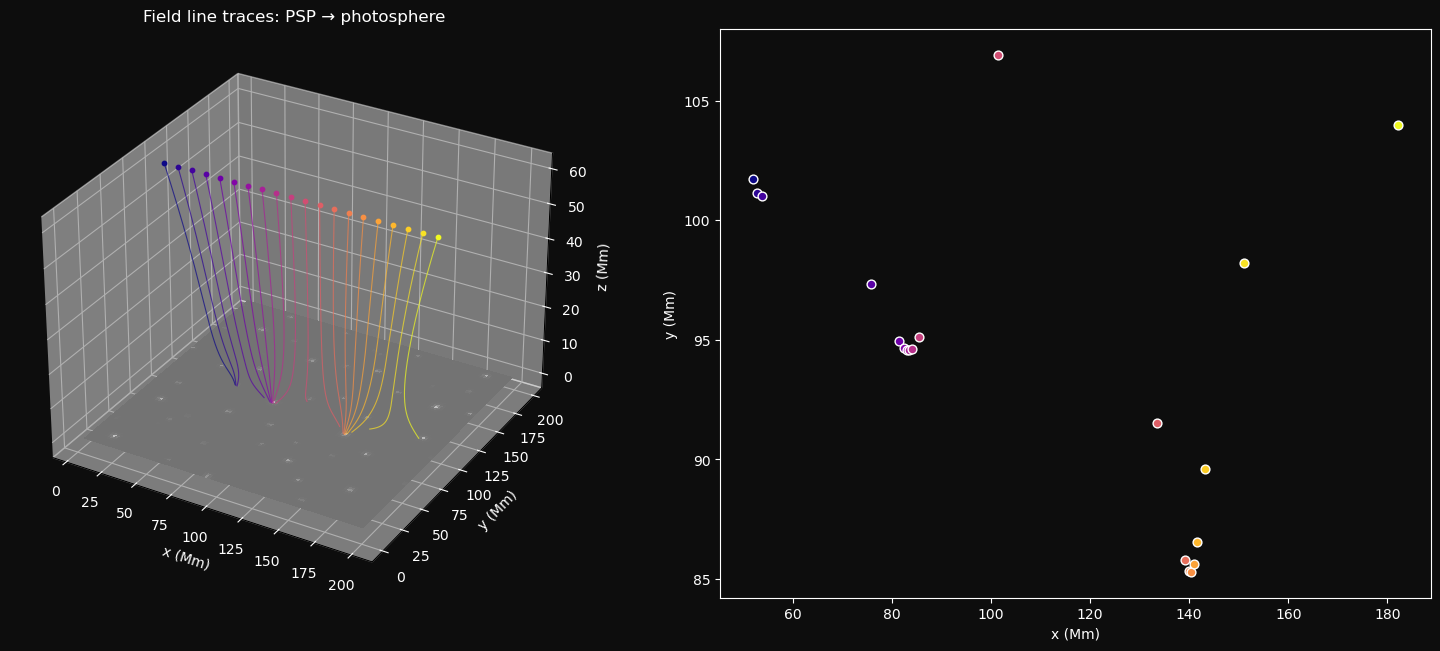

In [409]:
################# run #################
Z_PSP = 60 # 6000 # psp height in Mm
PSP_SPEED = 0.2 # Mm /s 
ds = 0.05 # 0.05 # Mm
subsample = 50

print(f'trace step length: {ds * 1000} km')


t, x_psp, y_psp, z_psp_arr = make_psp_trajectory(z_psp=Z_PSP, speed=PSP_SPEED, y_offset=0, dt=1.0)
x_foot, y_foot, B_foot, B_psp, idx = trace_all_footpoints(x_psp, y_psp, z_psp_arr, xi, yi, phi, ds=ds, subsample=subsample)

dt_sample = t[subsample] - t[0]  # time between each traced point
print(f'Time between sampled points: {dt_sample:.2f} s')

plot_fieldline_traces(x_psp, y_psp, z_psp_arr, t,
                      xi, yi, phi,
                      ds=ds,       # step size in Mm
                      subsample=subsample) # every Nth PSP point

Text(0.5, 0, 'Time [s]')

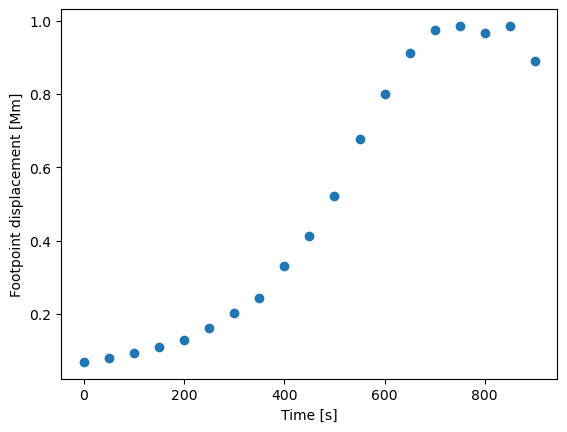

In [406]:
t = np.arange(len(x_foot))

displacement = np.sqrt(x_foot**2 + y_foot**2)

footpoint_speed = np.diff(displacement) / dt_sample

plt.scatter((t*dt_sample)[:-1], np.diff(displacement))
plt.ylabel('Footpoint displacement [Mm]')
plt.xlabel('Time [s]')

Text(0.5, 0, 'Footpoint speed [Mm / s]')

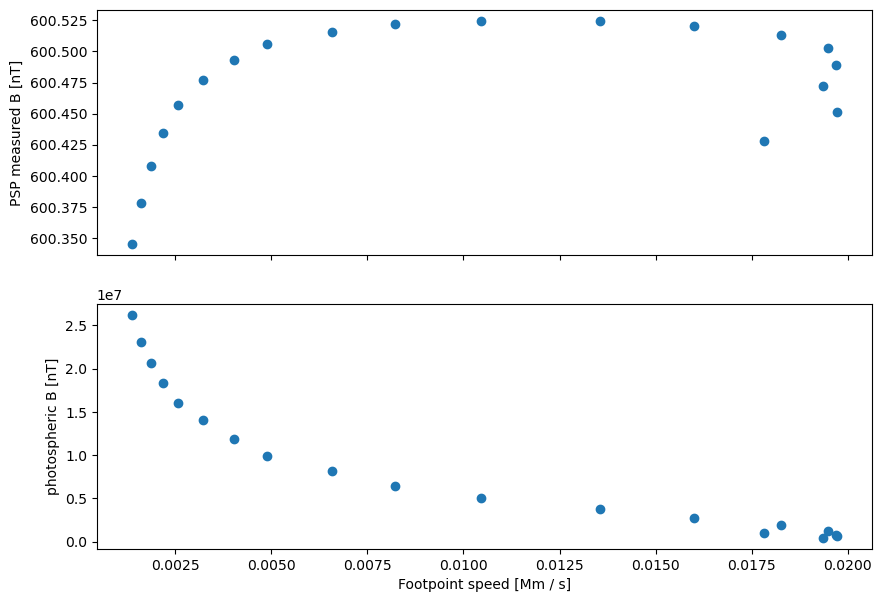

In [407]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

ax[0].scatter(footpoint_speed, B_psp[:-1])
ax[0].set_ylabel('PSP measured B [nT]')

ax[1].scatter(footpoint_speed, B_foot[:-1])
ax[1].set_ylabel('photospheric B [nT]')
ax[1].set_xlabel('Footpoint speed [Mm / s]')